In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
Raw_Data = pd.read_csv("Raw_data.csv")

# Assigning predefined column names because the exported HMI file contains two unnamed columns.
Raw_Data = pd.DataFrame(Raw_Data , columns = ["Time","Feedingscrew_F","Feedingscrew_Am","Rotarywing_F",
                                                  "Rotarywing_Am","IDfan_F","IDfan_A","Temp_Inlet" ,
                                                  "Temp_Outlet","Temp_Exhaust","Feed(kg/min)","Stage"
                                                  ,"Status"])

In [21]:
### Data Prepration

In [ ]:

# Rename the columns name
Raw_Data = Raw_Data.rename(columns={"Time":"time","Feedingscrew_F": "feedingscrew_freq",
                                     "Feedingscrew_Am": "feedingscrew_amp" , 
                                     "Rotarywing_F": "rotarywing_freq",
                                     "Rotarywing_Am": "rotarywing_amp" , 
                                     "IDfan_F": "IDfan_freq" ,
                                     "IDfan_A": "IDfan_amp",
                                     "Temp_Inlet": "temp_inlet" ,
                                     "Temp_Outlet": "temp_outlet" ,
                                     "Temp_Exhaust": "temp_exhaust" ,
                                     "Feed(kg/min)": "feeding_rate"})

# Data inspection in first stage
print (f" the data shape is:\n {Raw_Data.shape}")
print (f" data type in columns is:\n {Raw_Data.dtypes}")

#  Nulls Report & Desicioning
null_report = pd.DataFrame({
    "Null Count": Raw_Data.isnull().sum(),
    "Null Percent": (Raw_Data.isnull().mean() * 100).round(2)})
print (f"here is null reports:\n {null_report} ")

#checking Uniqe values
print (f'the uniqe value of Feeding rate is:{Raw_Data["feeding_rate"].unique()} the feeding rate is increased and decreased in a stepwise manner.' )

# Removing exctra columns that are nulls
print (f'\n based on the null & uniqe values two columns {"Stage" , "Status"} will be deleted')
Raw_Data = Raw_Data.drop(columns = ["Stage" , "Status"])


In [23]:
### Data Validation

In [ ]:
# Range of numeric parameters
summary = pd.DataFrame({
    "Min": Raw_Data.min(numeric_only=True),
    "Max": Raw_Data.max(numeric_only=True),
})
summary["Range"] = summary["Max"] - summary["Min"]
print(summary)

# Parameter modification (rotarywing_amp)
print (Raw_Data.loc[Raw_Data["rotarywing_amp"] < 0, "rotarywing_amp"].describe())
Raw_Data.loc[Raw_Data["rotarywing_amp"] < 0, "rotarywing_amp"] = 0


In [ ]:
# checking valuse
print (Raw_Data.dtypes)
print (Raw_Data.info())
print (Raw_Data.describe())
print (Raw_Data.tail(6))
print (Raw_Data.head(11))

In [ ]:
# Time Serie Data
print (f"the data type is: {Raw_Data.dtypes['time']}")
Raw_Data["time"] = pd.to_datetime(Raw_Data["time"])
print (f"the data type now is: {Raw_Data.dtypes['time']}")

Raw_Data = Raw_Data.sort_values("time")
Raw_Data["time_Diff"] = Raw_Data["time"].diff()
print(Raw_Data["time_Diff"])
print(Raw_Data["time"].diff().value_counts())
print ('Data logging has been performed regularly at one-minute intervals.')

In [27]:
#setting time as index
# Raw_Data.set_index("time", inplace=True)
# # print (Raw_Data.index)
# # seperating Date & Hour 
# Raw_Data["Date"] = Raw_Data.index.date
# Raw_Data["Hour"] = Raw_Data.index.hour
# print (Raw_Data["Hour"])
# print (Raw_Data["Date"])
# print (Raw_Data.dtypes)
# print (f" the data shape is:\n {Raw_Data.shape}")

In [28]:
# saving the clean date as csv file
Raw_Data.to_csv("hmi_data.csv", index=False)
hmi_data = Raw_Data

In [29]:
### saving new file
hmi_data = pd.read_csv("hmi_data.csv")
hmi_data["time"] = pd.to_datetime(hmi_data["time"])
print(hmi_data["time"].dtype)


datetime64[ns]


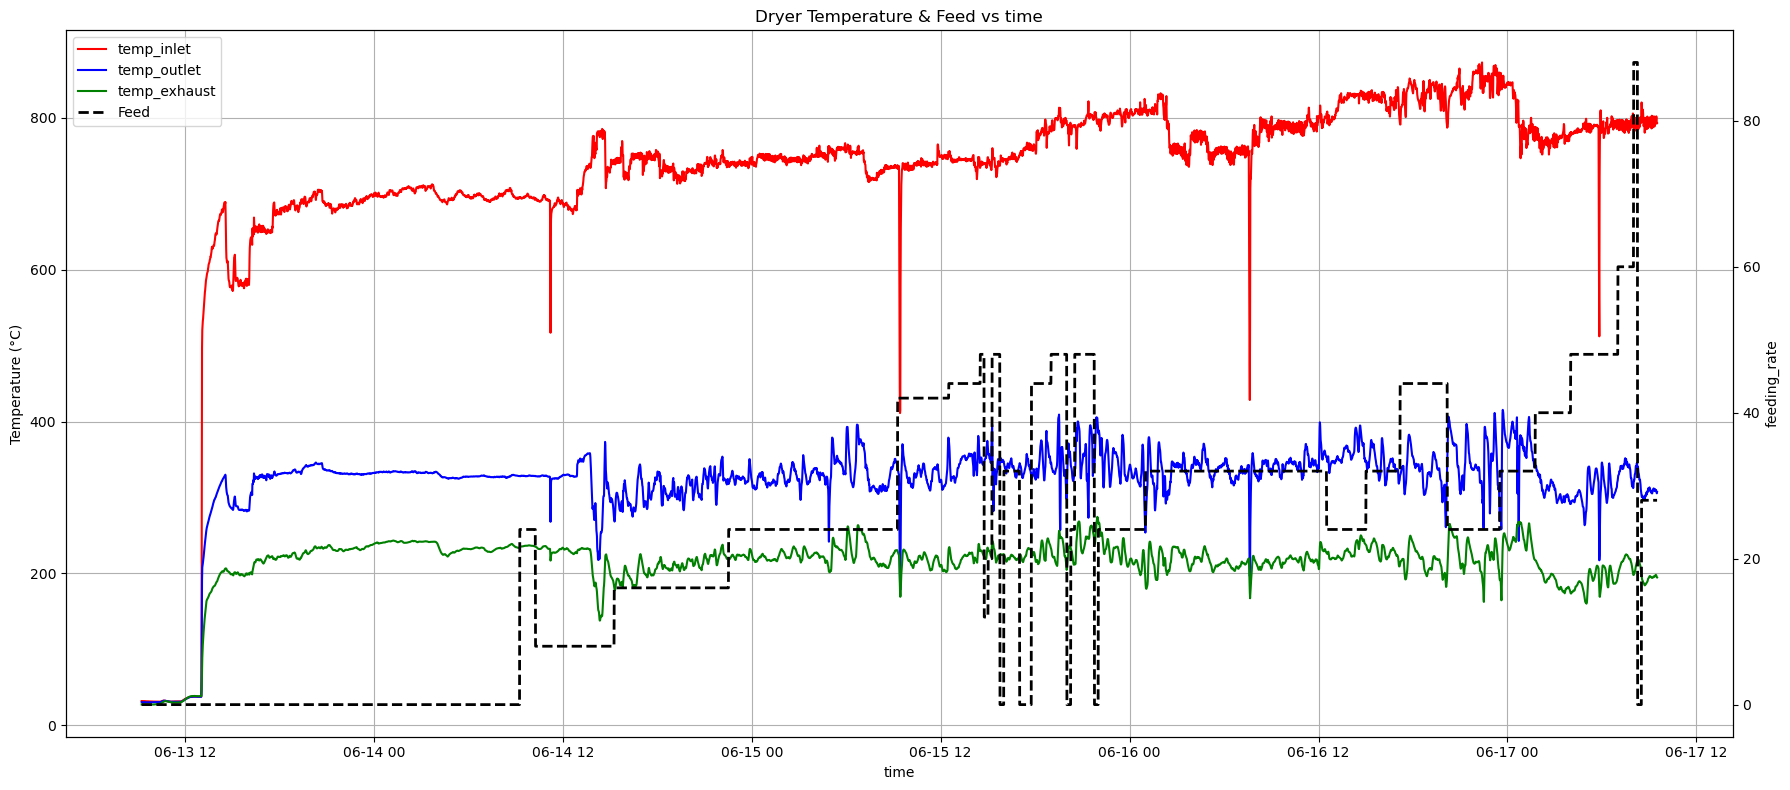

In [36]:
# Plot Temperatures

fig, ax1 = plt.subplots(figsize=(18,8))

ax1.plot(hmi_data["time"], hmi_data["temp_inlet"], color='red', label='temp_inlet')
ax1.plot(hmi_data["time"], hmi_data["temp_outlet"], color='blue', label='temp_outlet')
ax1.plot(hmi_data["time"], hmi_data["temp_exhaust"], color='green', label='temp_exhaust')

ax1.set_xlabel("time")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hmi_data["time"], hmi_data["feeding_rate"],
         color='black',
         linestyle='--',
         linewidth=2,
         label='Feed')
ax2.set_ylabel("feeding_rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Dryer Temperature & Feed vs time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


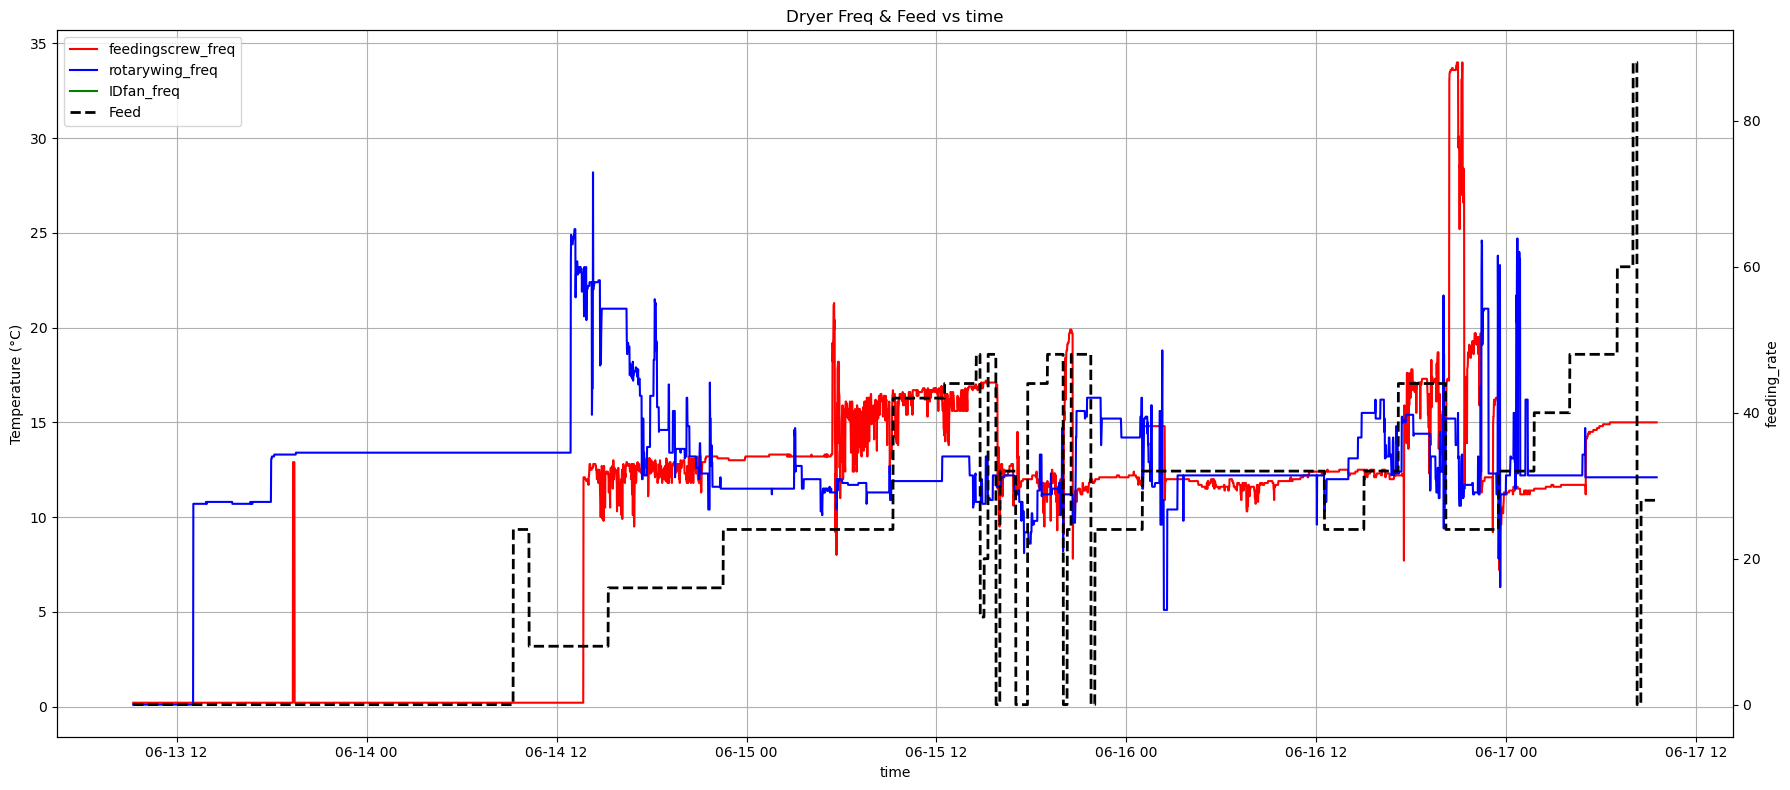

In [34]:
# Plot Equipement Freq

fig, ax1 = plt.subplots(figsize=(18,8))

ax1.plot(hmi_data["time"], hmi_data["feedingscrew_freq"], color='red', label='feedingscrew_freq')
ax1.plot(hmi_data["time"], hmi_data["rotarywing_freq"], color='blue', label='rotarywing_freq')
ax1.plot(hmi_data["time"], hmi_data["IDfan_freq"], color='green', label='IDfan_freq')

ax1.set_xlabel("time")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hmi_data["time"], hmi_data["feeding_rate"],
         color='black',
         linestyle='--',
         linewidth=2,
         label='Feed')
ax2.set_ylabel("feeding_rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Dryer Freq & Feed vs time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

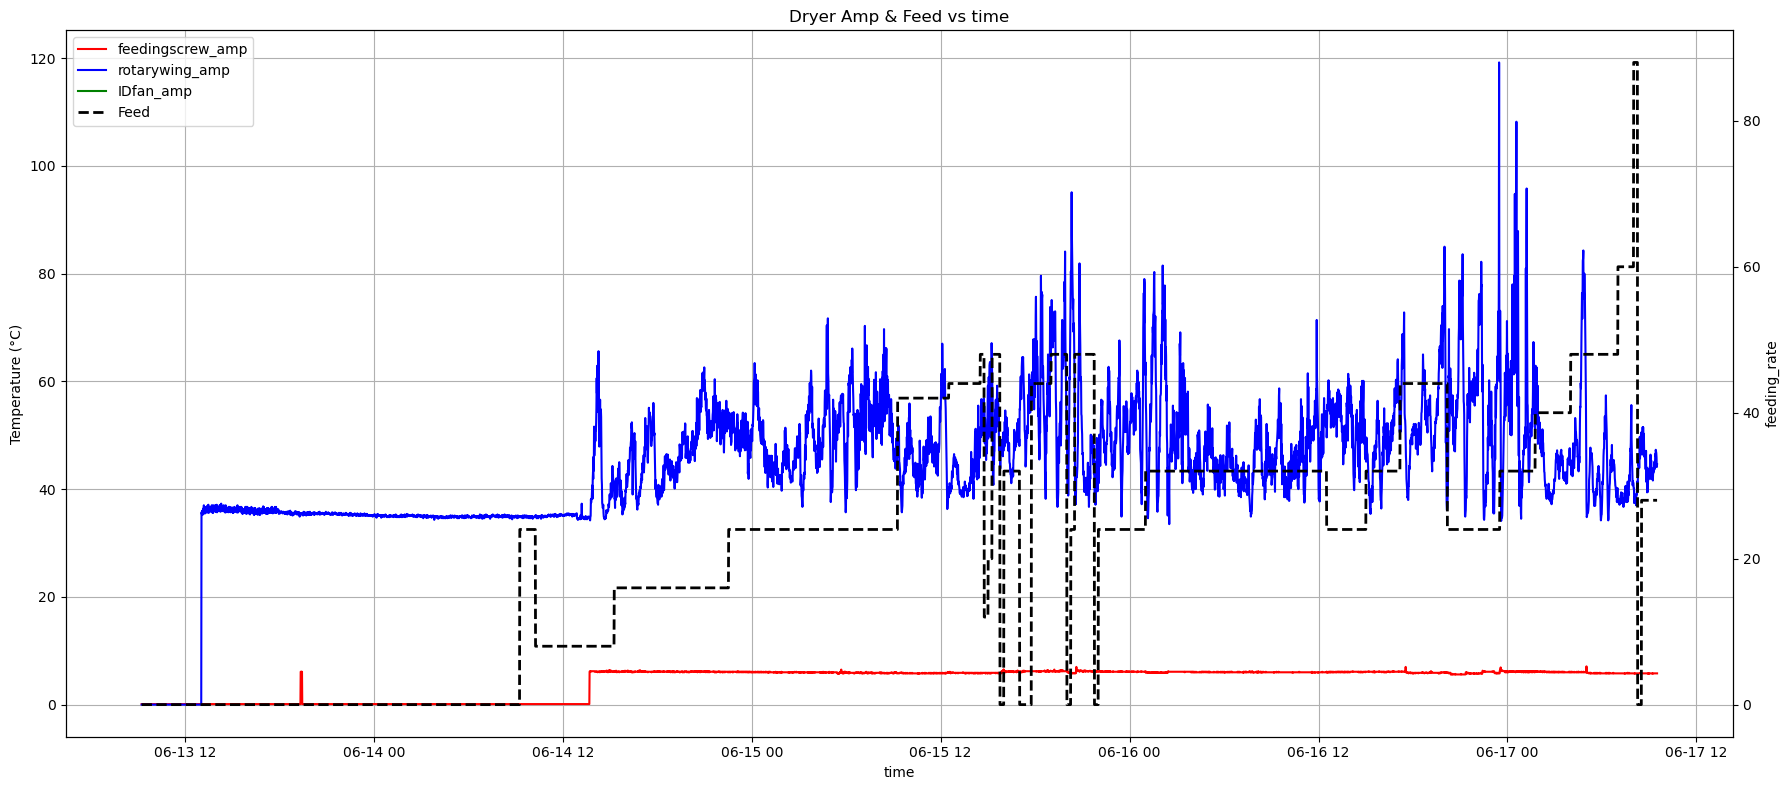

In [35]:
# Plot Equipement Am

fig, ax1 = plt.subplots(figsize=(18,8))

ax1.plot(hmi_data["time"], hmi_data["feedingscrew_amp"], color='red', label='feedingscrew_amp')
ax1.plot(hmi_data["time"], hmi_data["rotarywing_amp"], color='blue', label='rotarywing_amp')
ax1.plot(hmi_data["time"], hmi_data["IDfan_amp"], color='green', label='IDfan_amp')

ax1.set_xlabel("time")
ax1.set_ylabel("Temperature (°C)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hmi_data["time"], hmi_data["feeding_rate"],
         color='black',
         linestyle='--',
         linewidth=2,
         label='Feed')
ax2.set_ylabel("feeding_rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Dryer Amp & Feed vs time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### 